# 05 — Efficacités de Types

> **Objectif** : construire la table des types depuis le CSV, analyser les profils défensifs (faiblesses, résistances, immunités) et offensifs (couverture STAB) pour les mono et dual-types.

**Prérequis** : avoir exécuté `01_chargement_nettoyage.ipynb`


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import ast

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F5F6FA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

TYPE_COLORS = {
    'normal': '#A8A878', 'fire': '#F08030', 'water': '#6890F0', 'electric': '#F8D030',
    'grass': '#78C850', 'ice': '#98D8D8', 'fighting': '#C03028', 'poison': '#A040A0',
    'ground': '#E0C068', 'flying': '#A890F0', 'psychic': '#F85888', 'bug': '#A8B820',
    'rock': '#B8A038', 'ghost': '#705898', 'dragon': '#7038F8', 'dark': '#705848',
    'steel': '#B8B8D0', 'fairy': '#EE99AC', 'stellar': '#40B5A5',
}

with open('../data/pokemon_processed.pkl', 'rb') as f:
    df = pickle.load(f)
print(f'Données chargées : {df.shape[0]} Pokémon')

Données chargées : 1025 Pokémon


## 1. Construction de la matrice des types


In [10]:
types_df = pd.read_csv('../data/pokemon_types.csv')
types_df['doubles_damage_to'] = types_df['doubles_damage_to'].apply(ast.literal_eval)
types_df['half_damage_to']    = types_df['half_damage_to'].apply(ast.literal_eval)
types_df['no_damage_to']      = types_df['no_damage_to'].apply(ast.literal_eval)

ALL_TYPES = types_df['name'].tolist()

matrix = pd.DataFrame(1.0, index=ALL_TYPES, columns=ALL_TYPES)
for _, row in types_df.iterrows():
    att = row['name']
    for defe in row['doubles_damage_to']:
        if defe in matrix.columns:
            matrix.loc[att, defe] = 2.0
    for defe in row['half_damage_to']:
        if defe in matrix.columns:
            matrix.loc[att, defe] = 0.5
    for defe in row['no_damage_to']:
        if defe in matrix.columns:
            matrix.loc[att, defe] = 0.0

print(f'Matrice construite : {len(ALL_TYPES)} types')

Matrice construite : 19 types


## 2. Heatmap — Table des types


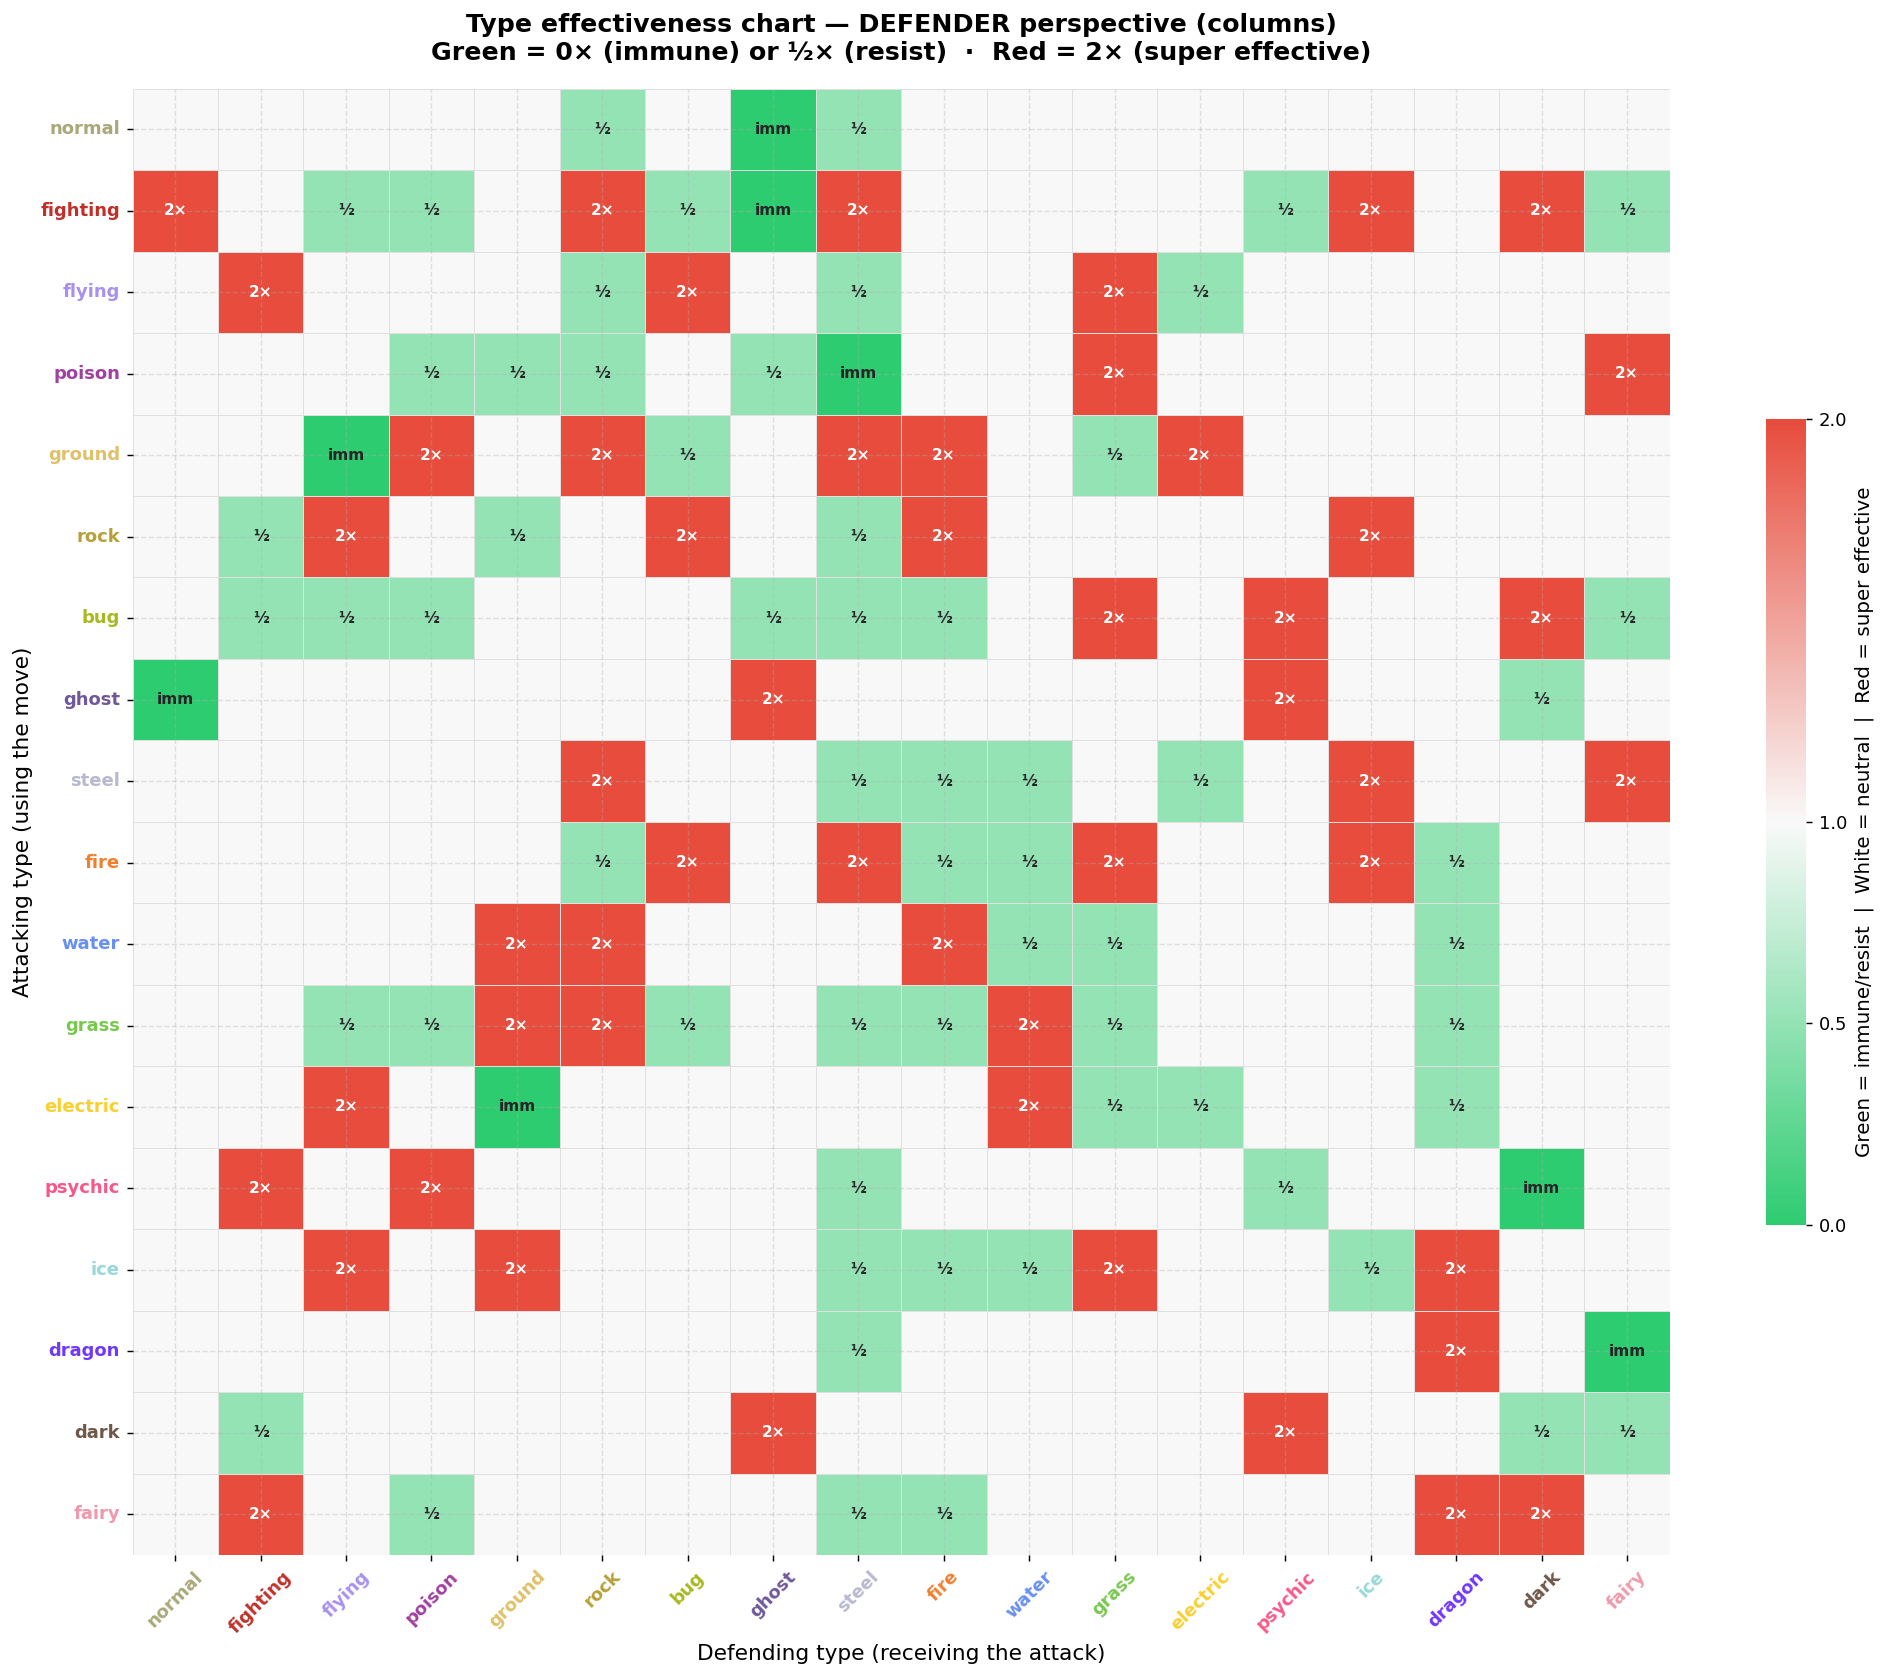

In [11]:
from matplotlib.colors import LinearSegmentedColormap
cmap_types = LinearSegmentedColormap.from_list(
    'type_eff', ['#2ECC71', '#F9F9F9', '#E74C3C'], N=256
)

fig, ax = plt.subplots(figsize=(16, 13))

display_types = [t for t in ALL_TYPES if t != 'stellar']
mat_display = matrix.loc[display_types, display_types]

def fmt_val(v):
    if v == 0:   return 'imm'
    if v == 0.5: return '½'
    if v == 2.0: return '2×'
    return ''

annot = mat_display.map(fmt_val)

sns.heatmap(
    mat_display,
    annot=annot, fmt='',
    cmap=cmap_types,
    center=1, vmin=0, vmax=2,
    linewidths=0.5, linecolor='#E0E0E0',
    ax=ax,
    cbar_kws={
        'shrink': 0.55,
        'label': 'Green = immune/resist  |  White = neutral  |  Red = super effective',
        'ticks': [0, 0.5, 1, 2]
    },
    annot_kws={'size': 8.5, 'weight': 'bold'}
)

ax.set_title(
    'Type effectiveness chart — DEFENDER perspective (columns)\n'
    'Green = 0× (immune) or ½× (resist)  ·  Red = 2× (super effective)',
    pad=16, fontsize=14
)
ax.set_xlabel('Defending type (receiving the attack)', fontsize=12)
ax.set_ylabel('Attacking type (using the move)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

for i, t in enumerate(display_types):
    ax.get_xticklabels()[i].set_color(TYPE_COLORS.get(t, '#333'))
    ax.get_xticklabels()[i].set_fontweight('bold')
    ax.get_yticklabels()[i].set_color(TYPE_COLORS.get(t, '#333'))
    ax.get_yticklabels()[i].set_fontweight('bold')

plt.tight_layout()
plt.show()

## 3. Calcul des profils défensifs et offensifs


In [12]:
def defense_profile(types):
    return {att: float(np.prod([matrix.loc[att, t] for t in types if t in matrix.columns]))
            for att in ALL_TYPES}

def offensive_coverage(types):
    covered = set()
    for att in types:
        if att in matrix.index:
            covered.update(t for t in ALL_TYPES if matrix.loc[att, t] == 2)
    return covered

df['defense_profile']  = df['types'].apply(defense_profile)
df['offense_coverage'] = df['types'].apply(offensive_coverage)
df['n_weaknesses']     = df['defense_profile'].apply(lambda p: sum(1 for v in p.values() if v > 1))
df['n_resistances']    = df['defense_profile'].apply(lambda p: sum(1 for v in p.values() if 0 < v < 1))
df['n_immunities']     = df['defense_profile'].apply(lambda p: sum(1 for v in p.values() if v == 0))
df['n_offense']        = df['offense_coverage'].apply(len)
df['defense_score']    = df['n_resistances'] + 2*df['n_immunities'] - df['n_weaknesses']

print('Profils calculés')

Profils calculés


## 4. Couverture offensive par type attaquant


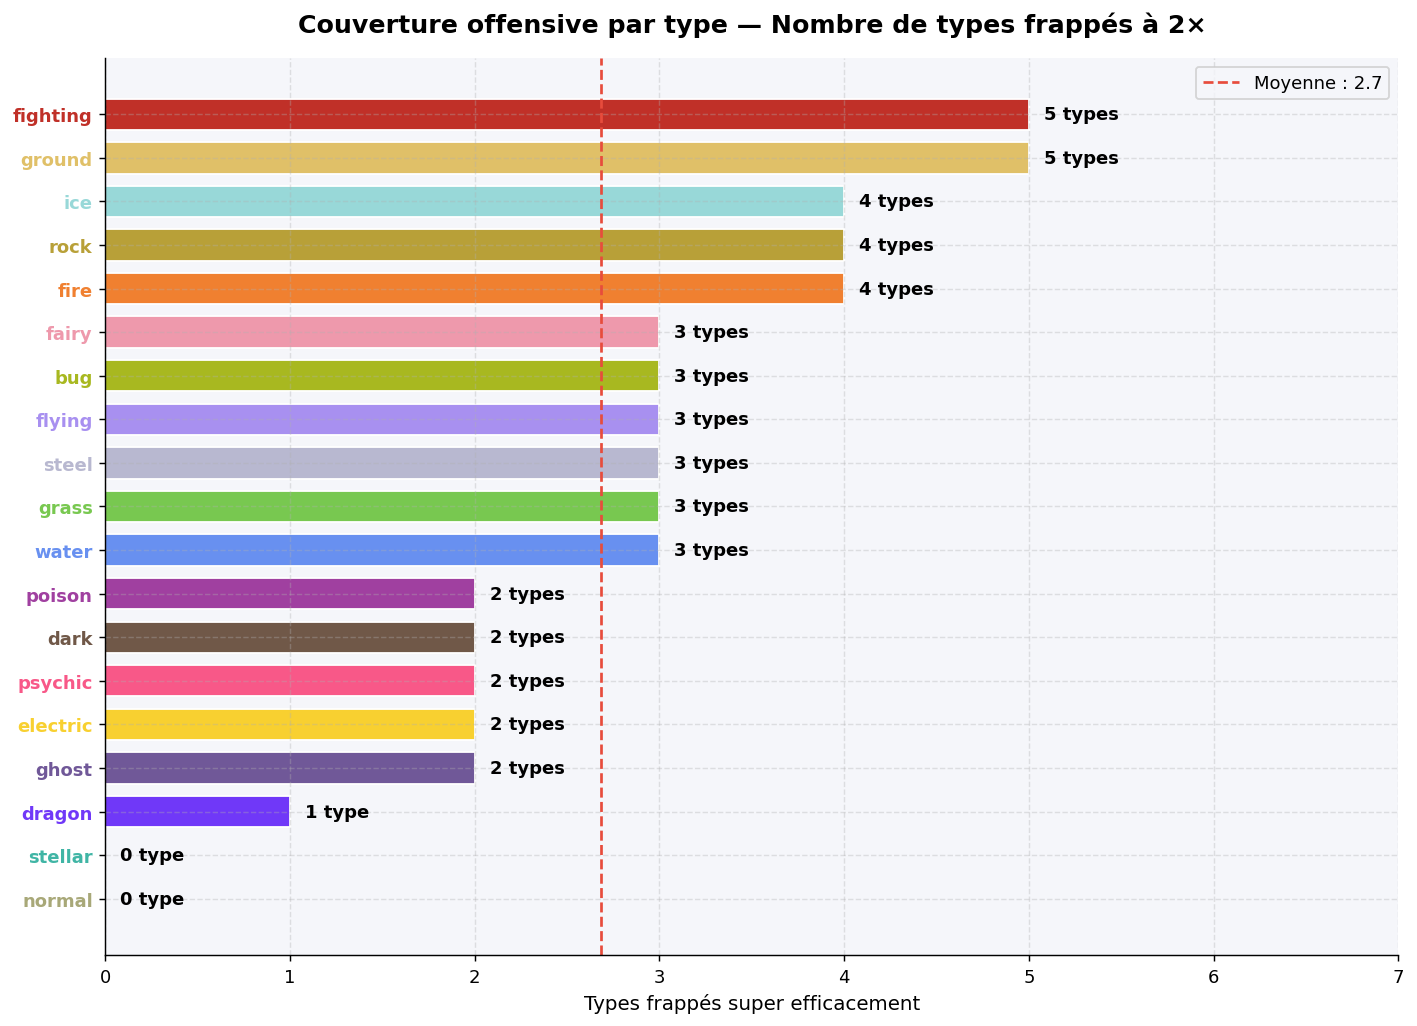

In [13]:
off_count = {t: int((matrix.loc[t] == 2).sum()) for t in ALL_TYPES}
off_series = pd.Series(off_count).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
bar_colors = [TYPE_COLORS.get(t, '#888') for t in off_series.index]
bars = ax.barh(off_series.index, off_series.values,
               color=bar_colors, edgecolor='white', linewidth=1, height=0.72)

for bar, val in zip(bars, off_series.values):
    ax.text(bar.get_width() + 0.08, bar.get_y() + bar.get_height()/2,
            f'{val} type{"s" if val > 1 else ""}', va='center', fontsize=10, fontweight='bold')

for i, t in enumerate(off_series.index):
    ax.get_yticklabels()[i].set_color(TYPE_COLORS.get(t, '#333'))
    ax.get_yticklabels()[i].set_fontweight('bold')

ax.set_title('Couverture offensive par type — Nombre de types frappés à 2×', pad=14)
ax.set_xlabel('Types frappés super efficacement')
ax.set_xlim(0, off_series.max() + 2)
ax.axvline(off_series.mean(), color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Moyenne : {off_series.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Profil défensif — Mono-types & Top dual-types


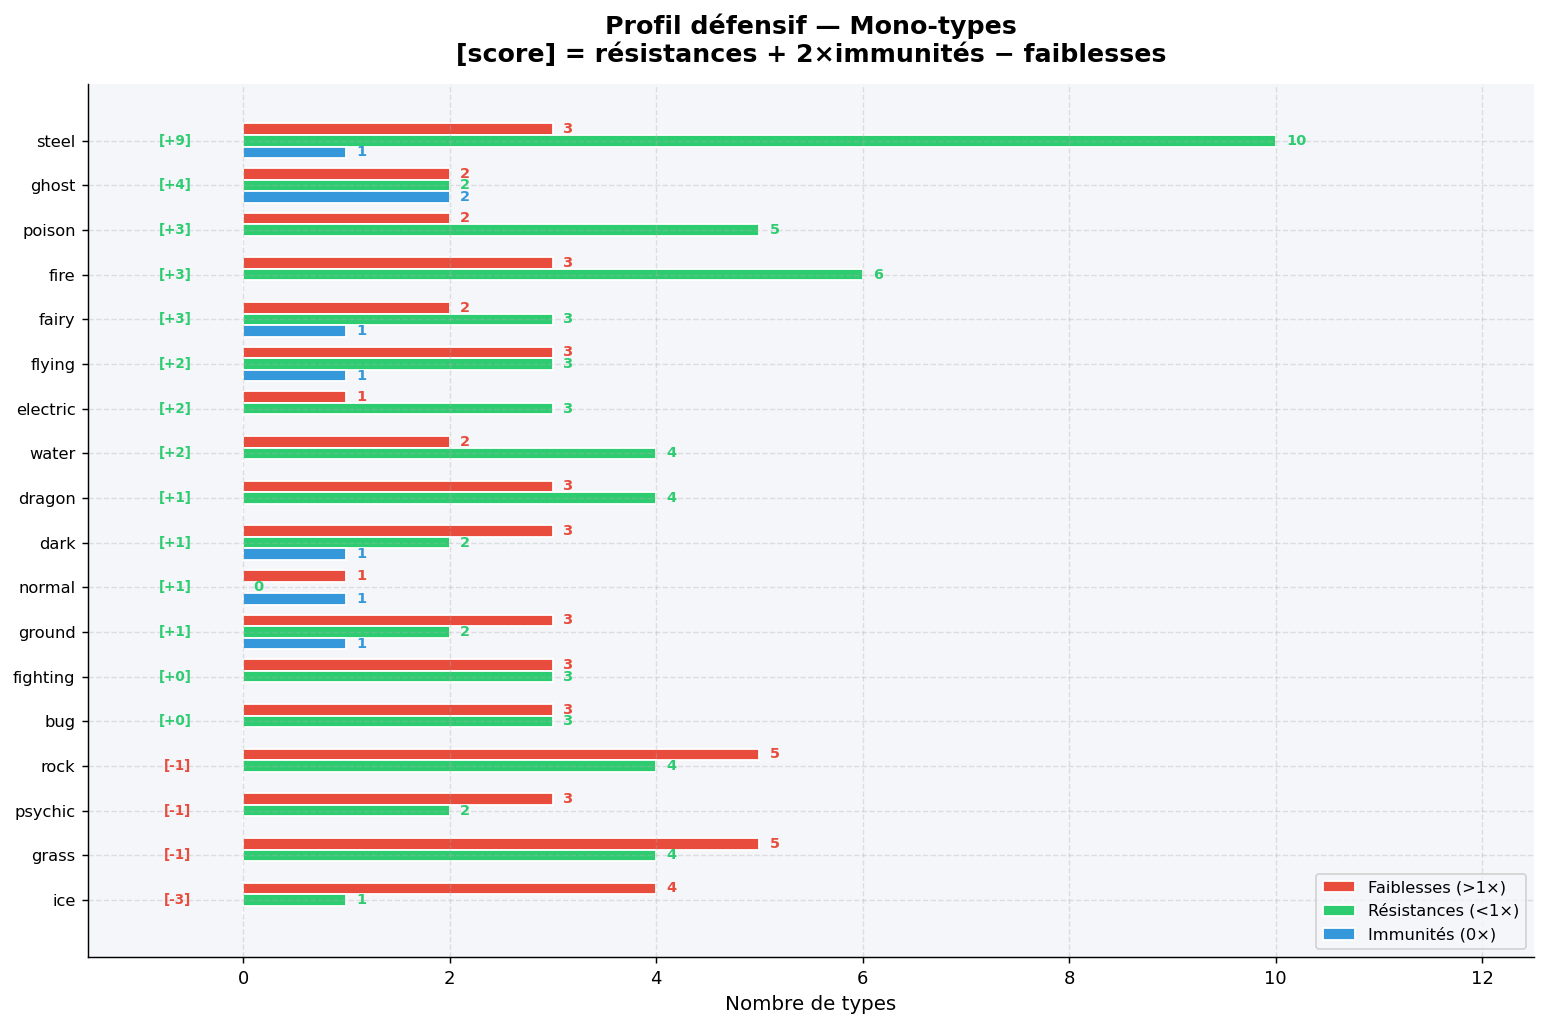

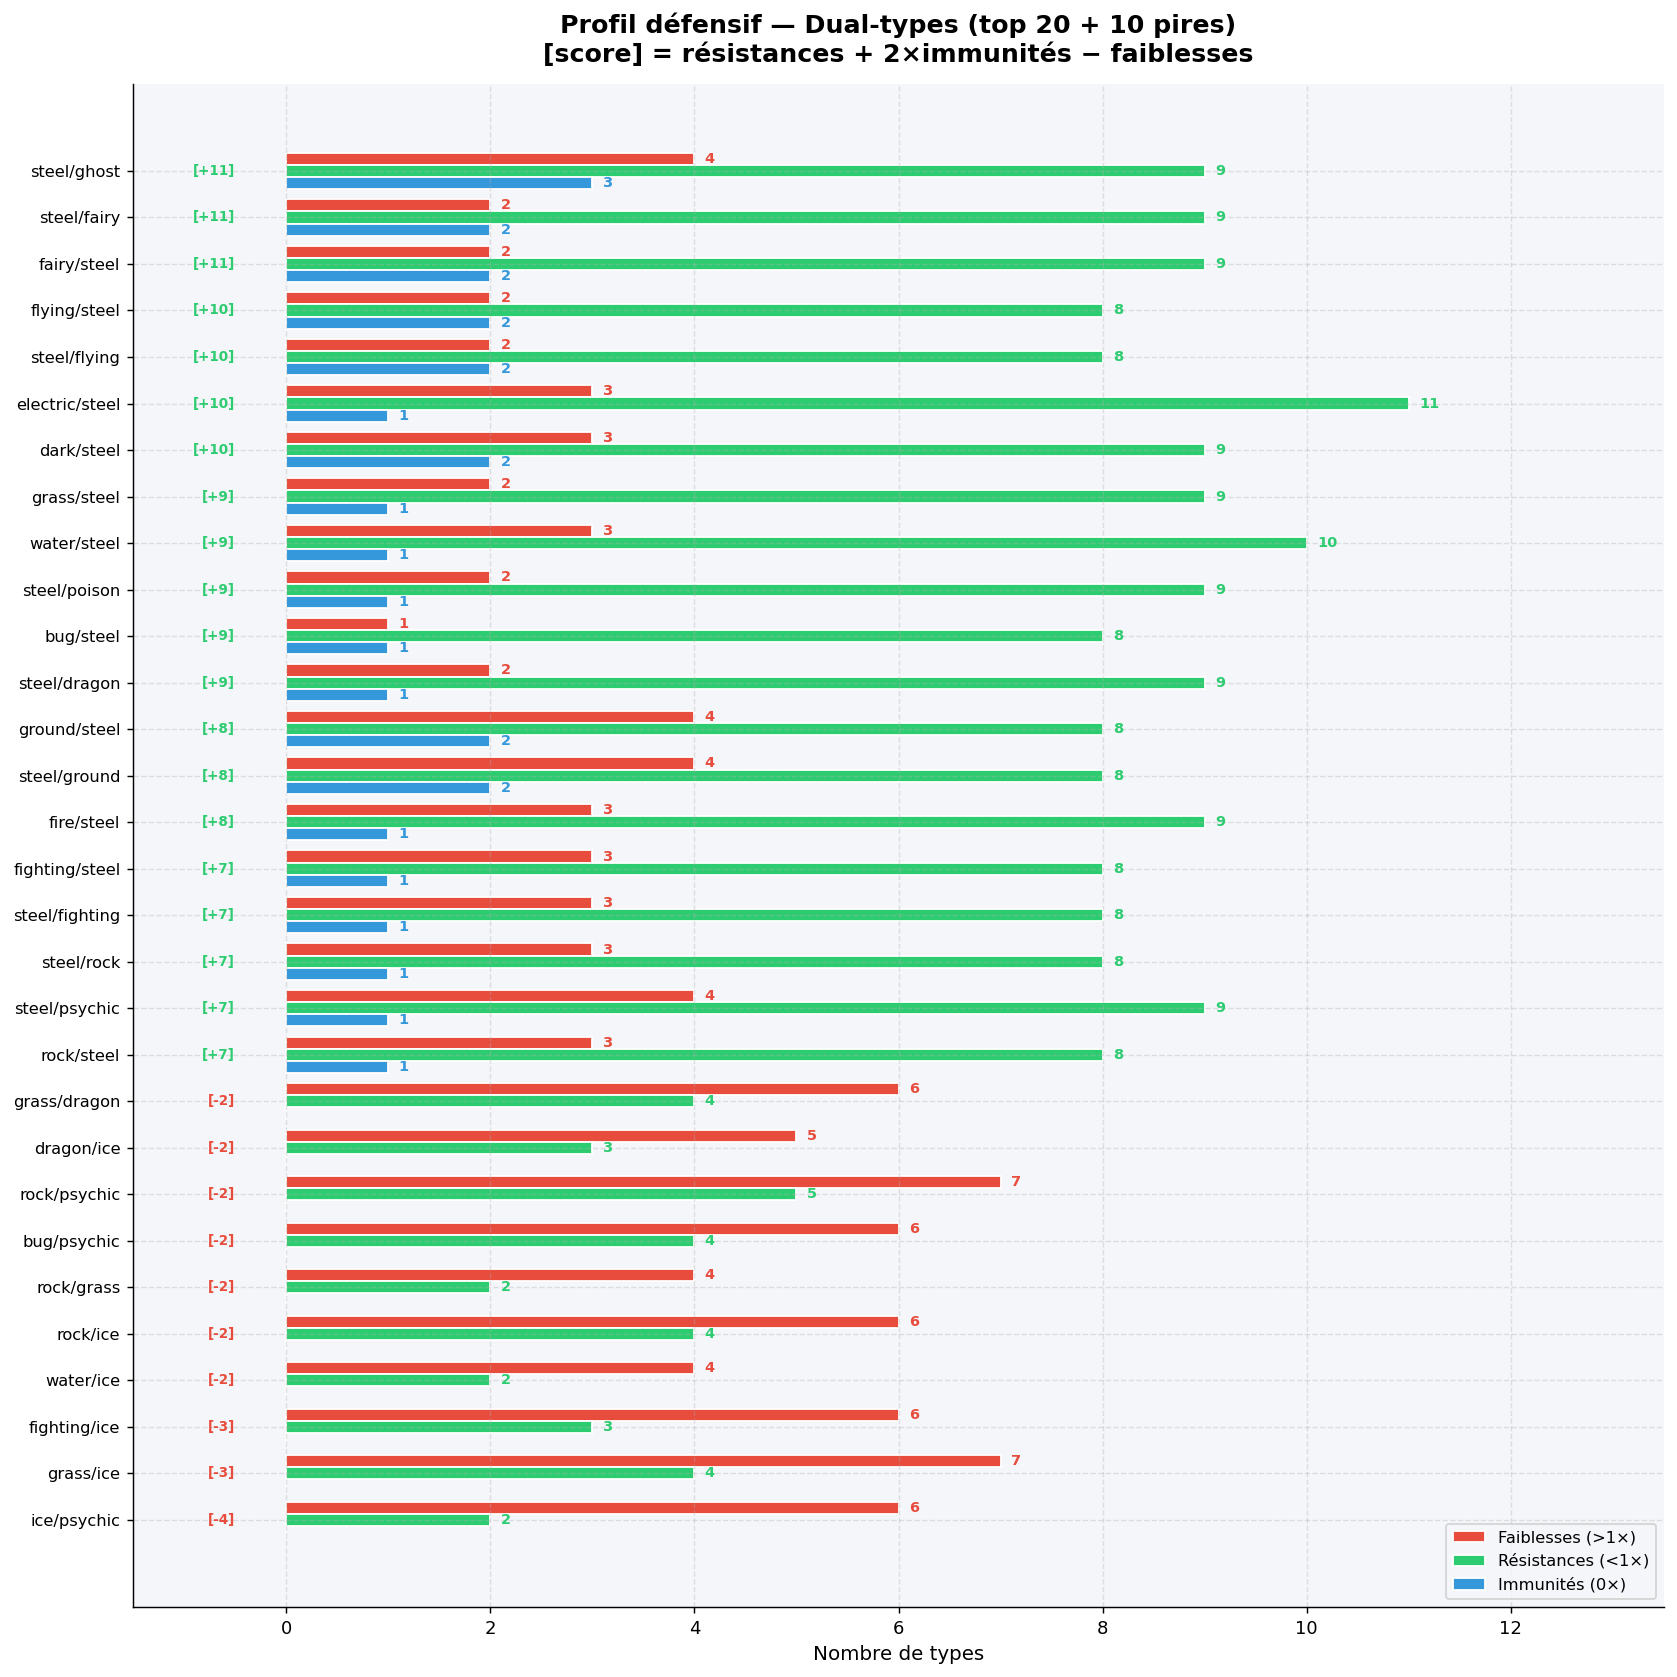


Top 10 meilleures combinaisons défensives :


,label,n_weaknesses,n_resistances,n_immunities,defense_score
0,steel/fairy,2,9,2,11
1,fairy/steel,2,9,2,11
2,steel/ghost,4,9,3,11
3,dark/steel,3,9,2,10
4,flying/steel,2,8,2,10
5,electric/steel,3,11,1,10
6,steel/flying,2,8,2,10
7,bug/steel,1,8,1,9
8,water/steel,3,10,1,9
9,grass/steel,2,9,1,9


In [14]:
type_combos = df[['type1', 'type2']].drop_duplicates().reset_index(drop=True)

records = []
for _, row in type_combos.iterrows():
    types   = [row['type1']] if pd.isna(row['type2']) else [row['type1'], row['type2']]
    label   = row['type1'] if pd.isna(row['type2']) else f"{row['type1']}/{row['type2']}"
    is_dual = not pd.isna(row['type2'])
    profile = defense_profile(types)
    n_weak  = sum(1 for v in profile.values() if v > 1)
    n_res   = sum(1 for v in profile.values() if 0 < v < 1)
    n_imm   = sum(1 for v in profile.values() if v == 0)
    covered = offensive_coverage(types)
    records.append({'label': label, 'type1': row['type1'], 'is_dual': is_dual,
                    'n_weaknesses': n_weak, 'n_resistances': n_res, 'n_immunities': n_imm,
                    'defense_score': n_res + 2*n_imm - n_weak,
                    'n_offense': len(covered), 'offense_coverage': covered})

combo_df = pd.DataFrame(records)
mono_df  = combo_df[~combo_df['is_dual']].sort_values('defense_score', ascending=True).reset_index(drop=True)
dual_df  = combo_df[combo_df['is_dual']].sort_values('defense_score', ascending=False)
top_dual = pd.concat([dual_df.head(20), dual_df.tail(10)]).drop_duplicates('label') \
             .sort_values('defense_score', ascending=True).reset_index(drop=True)

def grouped_barh(ax, data, title):
    y, h = np.arange(len(data)), 0.26
    b1 = ax.barh(y + h, data['n_weaknesses'],  h, color='#E74C3C', edgecolor='white', label='Faiblesses (>1×)')
    b2 = ax.barh(y,     data['n_resistances'], h, color='#2ECC71', edgecolor='white', label='Résistances (<1×)')
    b3 = ax.barh(y - h, data['n_immunities'],  h, color='#3498DB', edgecolor='white', label='Immunités (0×)')
    for i, (w, r, im) in enumerate(zip(data['n_weaknesses'], data['n_resistances'], data['n_immunities'])):
        ax.text(w + 0.1, i + h, str(w), va='center', fontsize=8, color='#E74C3C', fontweight='bold')
        ax.text(r + 0.1, i,     str(r), va='center', fontsize=8, color='#2ECC71', fontweight='bold')
        if im > 0:
            ax.text(im + 0.1, i - h, str(im), va='center', fontsize=8, color='#3498DB', fontweight='bold')
    score_col = data['defense_score'].values
    for i, s in enumerate(score_col):
        color = '#2ECC71' if s >= 0 else '#E74C3C'
        ax.text(-0.5, i, f'[{s:+d}]', va='center', ha='right', fontsize=7.5,
                color=color, fontweight='bold')
    ax.set_yticks(y)
    ax.set_yticklabels(data['label'], fontsize=9)
    ax.set_xlabel('Nombre de types')
    ax.set_title(title, pad=12)
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim(-1.5, data[['n_weaknesses','n_resistances','n_immunities']].max().max() + 2.5)

fig, ax = plt.subplots(figsize=(12, 8))
grouped_barh(ax, mono_df, 'Profil défensif — Mono-types\n[score] = résistances + 2×immunités − faiblesses')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 13))
grouped_barh(ax, top_dual, 'Profil défensif — Dual-types (top 20 + 10 pires)\n[score] = résistances + 2×immunités − faiblesses')
plt.tight_layout()
plt.show()

print('\nTop 10 meilleures combinaisons défensives :')
display(combo_df.sort_values('defense_score', ascending=False).head(10)
        [['label','n_weaknesses','n_resistances','n_immunities','defense_score']]
        .reset_index(drop=True))

## 6. Profil offensif — Mono-types & Top dual-types


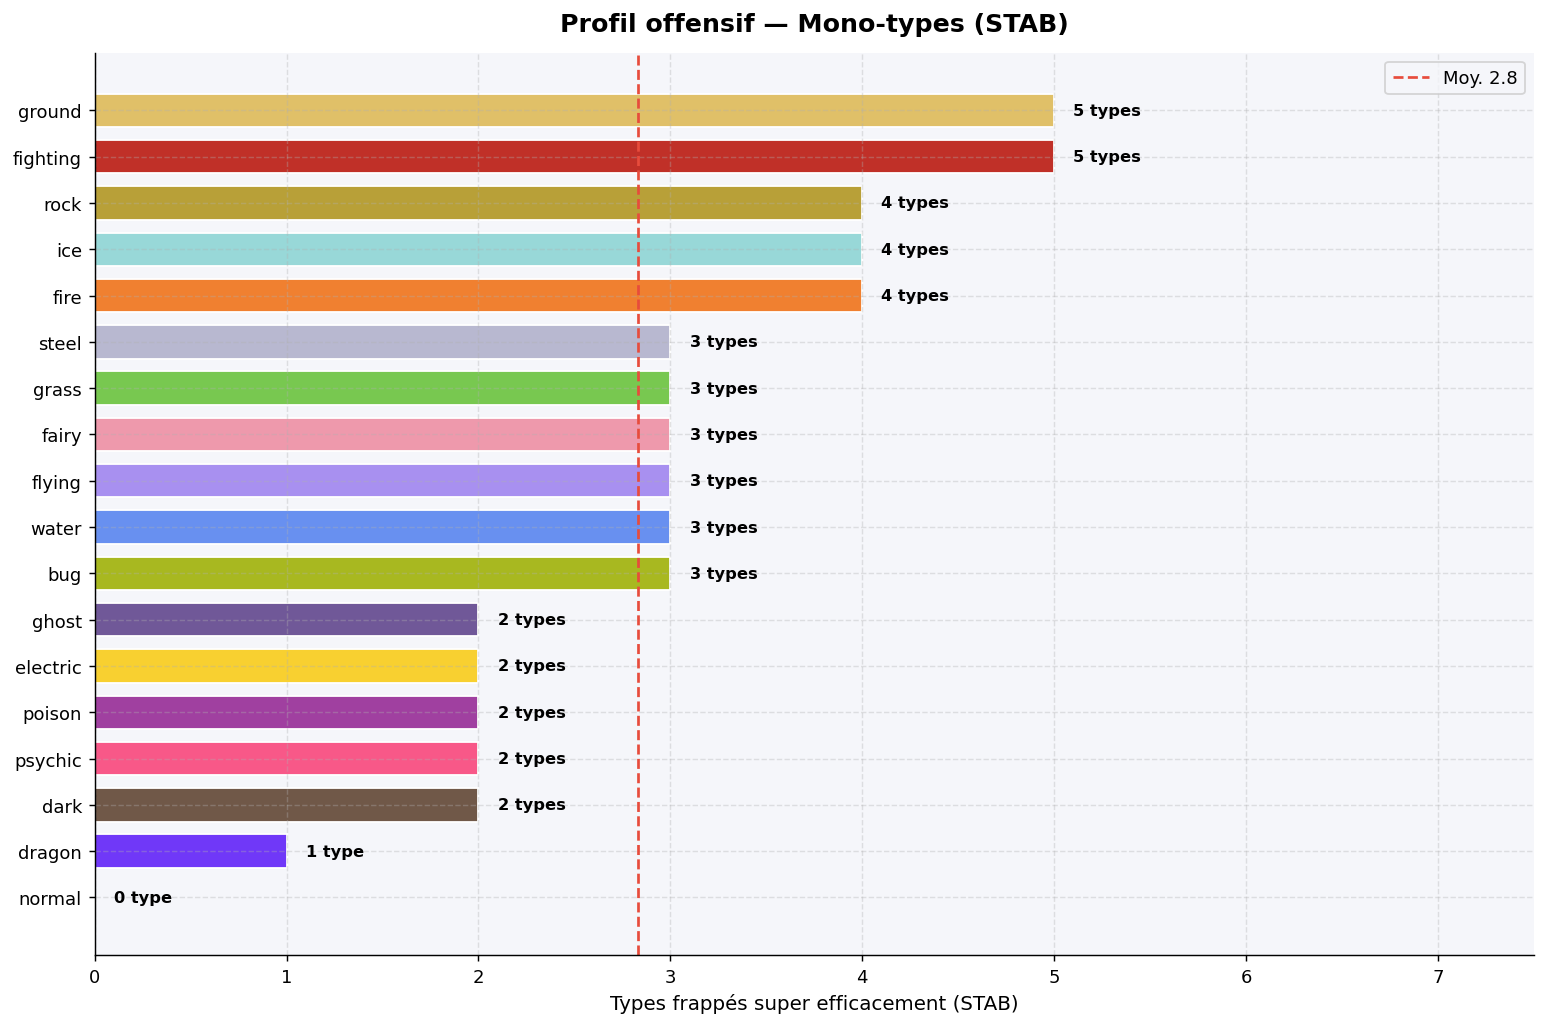

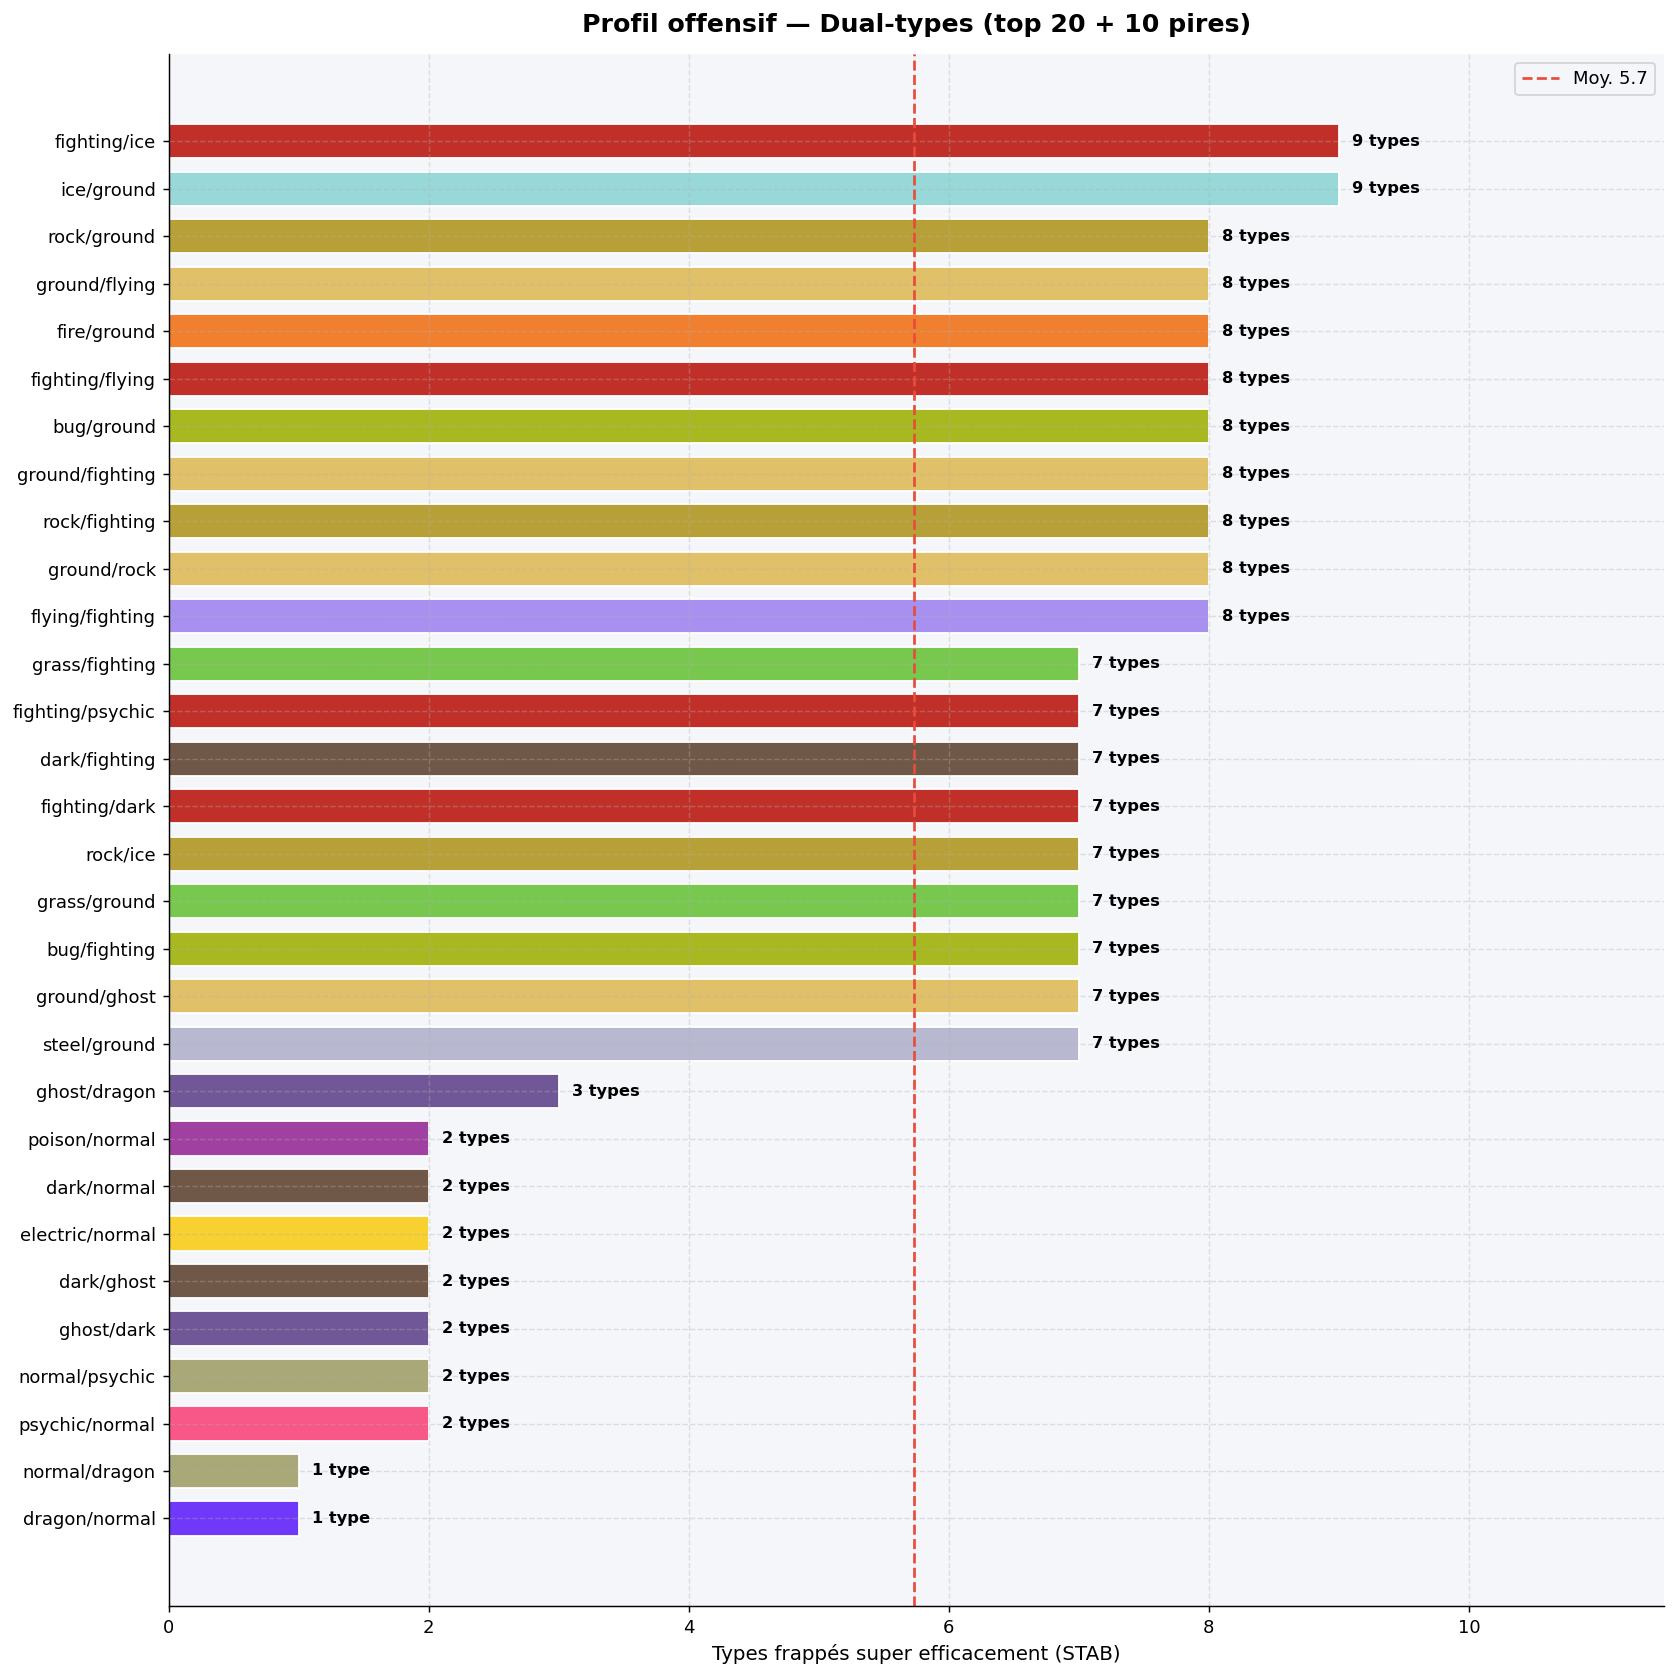

In [15]:
mono_off     = mono_df.sort_values('n_offense', ascending=True).reset_index(drop=True)
dual_off_top = combo_df[combo_df['is_dual']].sort_values('n_offense', ascending=False)
top_dual_off = pd.concat([dual_off_top.head(20), dual_off_top.tail(10)]).drop_duplicates('label') \
                 .sort_values('n_offense', ascending=True).reset_index(drop=True)

def offense_barh(ax, data, title):
    colors = [TYPE_COLORS.get(row['type1'], '#888') for _, row in data.iterrows()]
    bars   = ax.barh(data['label'], data['n_offense'],
                     color=colors, edgecolor='white', linewidth=1, height=0.72)
    for bar, val in zip(bars, data['n_offense']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(val)} type{"s" if val > 1 else ""}',
                va='center', fontsize=9, fontweight='bold')
    ax.axvline(data['n_offense'].mean(), color='#E74C3C', linestyle='--',
               linewidth=1.5, label=f'Moy. {data["n_offense"].mean():.1f}')
    ax.set_xlabel('Types frappés super efficacement (STAB)')
    ax.set_title(title, pad=12)
    ax.set_xlim(0, data['n_offense'].max() + 2.5)
    ax.legend()

fig, ax = plt.subplots(figsize=(12, 8))
offense_barh(ax, mono_off, 'Profil offensif — Mono-types (STAB)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 13))
offense_barh(ax, top_dual_off, 'Profil offensif — Dual-types (top 20 + 10 pires)')
plt.tight_layout()
plt.show()

## 7. Sauvegarde


In [16]:
with open('../data/pokemon_full.pkl', 'wb') as f:
    pickle.dump({'df': df, 'matrix': matrix, 'ALL_TYPES': ALL_TYPES}, f)
print('Données sauvegardées → ../data/pokemon_full.pkl')

Données sauvegardées → ../data/pokemon_full.pkl
